# Импорт библиотек

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tarfile #встроенный модуль для работы с tar-архивами
import os
import nibabel as nib
import random
import glob #встроенный модуль для поиска файлов, соответстсвующих определенному шаблону в дереве каталогов
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, concatenate, Conv2DTranspose, Activation, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K

2026-05-31 18:01:50.697863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780239711.347070   33375 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780239711.595463   33375 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780239713.527874   33375 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780239713.527900   33375 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780239713.527902   33375 computation_placer.cc:177] computation placer alr

In [2]:
print("GPU доступны:", tf.config.list_physical_devices('GPU'))

GPU доступны: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Работа с данными

In [4]:
file = tarfile.open('/mnt/e/BraTS2021_Training_Data.tar')

file.extractall('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data') #извлекли данные мрт из архива в папку по указанному пути
file.close()

In [5]:
scaler = MinMaxScaler()

In [6]:
t1ce_s = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data/*/*t1ce.nii.gz'))
flair_s = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data/*/*flair.nii.gz'))
t2_s = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data/*/*t2.nii.gz'))
masks = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data/*/*seg.nii.gz'))

In [8]:
for im in range(len(t1ce_s)):
    print('Обрабатываем МРТ под номером:', im + 1)
    temp_t1ce = nib.load(t1ce_s[im]).get_fdata()
    temp_t1ce = scaler.fit_transform(temp_t1ce.reshape(-1, temp_t1ce.shape[-1])).reshape(temp_t1ce.shape)
    
    temp_t2 = nib.load(t2_s[im]).get_fdata()
    temp_t2 = scaler.fit_transform(temp_t2.reshape(-1, temp_t2.shape[-1])).reshape(temp_t2.shape)
    
    temp_flair = nib.load(flair_s[im]).get_fdata()
    temp_flair = scaler.fit_transform(temp_flair.reshape(-1, temp_flair.shape[-1])).reshape(temp_flair.shape)
    
    temp_mask = nib.load(masks[im]).get_fdata()
    temp_mask = temp_mask.astype(np.uint8)
    temp_mask[temp_mask==4] = 3
    
    temp_combo = np.stack([temp_t1ce, temp_t2, temp_flair], axis = 3)
    
    temp_combo = temp_combo[56:184, 56:184, 13:141]
    temp_mask = temp_mask[56:184, 56:184, 13:141]
    
    temp_mask = to_categorical(temp_mask, num_classes=4)
    
    np.save(f'/mnt/e/BRaTS/archive (1)/Input/MRIs/MRI_{im}.npy', temp_combo)
    np.save(f'/mnt/e/BRaTS/archive (1)/Input/masks/mask_{im}.npy', temp_mask)

Обрабатываем МРТ под номером: 1
Обрабатываем МРТ под номером: 2
Обрабатываем МРТ под номером: 3
Обрабатываем МРТ под номером: 4
Обрабатываем МРТ под номером: 5
Обрабатываем МРТ под номером: 6
Обрабатываем МРТ под номером: 7
Обрабатываем МРТ под номером: 8
Обрабатываем МРТ под номером: 9
Обрабатываем МРТ под номером: 10
Обрабатываем МРТ под номером: 11
Обрабатываем МРТ под номером: 12
Обрабатываем МРТ под номером: 13
Обрабатываем МРТ под номером: 14
Обрабатываем МРТ под номером: 15
Обрабатываем МРТ под номером: 16
Обрабатываем МРТ под номером: 17
Обрабатываем МРТ под номером: 18
Обрабатываем МРТ под номером: 19
Обрабатываем МРТ под номером: 20
Обрабатываем МРТ под номером: 21
Обрабатываем МРТ под номером: 22
Обрабатываем МРТ под номером: 23
Обрабатываем МРТ под номером: 24
Обрабатываем МРТ под номером: 25
Обрабатываем МРТ под номером: 26
Обрабатываем МРТ под номером: 27
Обрабатываем МРТ под номером: 28
Обрабатываем МРТ под номером: 29
Обрабатываем МРТ под номером: 30
Обрабатываем МРТ по

In [5]:
base_path = r'/mnt/e/PKG - UPENN-GBM-NIfTI/splitted_dataset/test'
output_path = r'/mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test'

# Создаем выходные папки
os.makedirs(os.path.join(output_path, 'MRIs'), exist_ok=True)
os.makedirs(os.path.join(output_path, 'masks'), exist_ok=True)

# Инициализируем scaler
scaler = MinMaxScaler()

# Получаем списки файлов из соответствующих папок
t1_path = os.path.join(base_path, 't1')
flair_path = os.path.join(base_path, 'flair')
t2_path = os.path.join(base_path, 't2')
mask_path = os.path.join(base_path, 'mask')

# Поскольку t1ce может отсутствовать, используем t1gd или t1
# Проверяем наличие папок
t1ce_path = None
if os.path.exists(os.path.join(base_path, 't1gd')):
    t1ce_path = os.path.join(base_path, 't1gd')
    print("Найдена папка t1gd, используем как T1ce")
elif os.path.exists(t1_path):
    t1ce_path = t1_path
    print("Папка t1gd не найдена, используем t1 как T1ce")
else:
    raise FileNotFoundError("Не найдены папки t1gd или t1")

# Получаем отсортированные списки файлов
t1ce_files = sorted(glob.glob(os.path.join(t1ce_path, '*.nii.gz')))
flair_files = sorted(glob.glob(os.path.join(flair_path, '*.nii.gz')))
t2_files = sorted(glob.glob(os.path.join(t2_path, '*.nii.gz')))
mask_files = sorted(glob.glob(os.path.join(mask_path, '*.nii.gz')))

# Проверяем, что количество файлов совпадает
print(f"Найдено файлов:")
print(f"T1ce: {len(t1ce_files)}")
print(f"FLAIR: {len(flair_files)}")
print(f"T2: {len(t2_files)}")
print(f"Mask: {len(mask_files)}")

# Определяем минимальное количество файлов (на случай, если где-то меньше)
min_files = min(len(t1ce_files), len(flair_files), len(t2_files), len(mask_files))
print(f"Будет обработано файлов: {min_files}")

# Обрабатываем каждый набор снимков
for im in range(min_files):
    print(f'Обрабатываем МРТ под номером: {im + 1}/{min_files}')
    
    try:
        # Загружаем и нормализуем T1ce/T1gd
        temp_t1ce = nib.load(t1ce_files[im]).get_fdata()
        temp_t1ce = scaler.fit_transform(temp_t1ce.reshape(-1, temp_t1ce.shape[-1])).reshape(temp_t1ce.shape)
        
        # Загружаем и нормализуем T2
        temp_t2 = nib.load(t2_files[im]).get_fdata()
        temp_t2 = scaler.fit_transform(temp_t2.reshape(-1, temp_t2.shape[-1])).reshape(temp_t2.shape)
        
        # Загружаем и нормализуем FLAIR
        temp_flair = nib.load(flair_files[im]).get_fdata()
        temp_flair = scaler.fit_transform(temp_flair.reshape(-1, temp_flair.shape[-1])).reshape(temp_flair.shape)
        
        # Загружаем маску
        temp_mask = nib.load(mask_files[im]).get_fdata()
        temp_mask = temp_mask.astype(np.uint8)
        
        # Конвертируем метку 4 в 3 (как в исходном коде)
        temp_mask[temp_mask == 4] = 3
        
        # Проверяем размерности
        print(f"  Размеры: T1ce={temp_t1ce.shape}, FLAIR={temp_flair.shape}, T2={temp_t2.shape}, Mask={temp_mask.shape}")
        
        # Объединяем модальности в один массив (добавляем четвертое измерение)
        temp_combo = np.stack([temp_t1ce, temp_t2, temp_flair], axis=3)
        
        # Обрезка как в исходном коде
        # Важно: размеры могут отличаться от BraTS, поэтому проверяем
        z_dim = temp_combo.shape[2]
        x_dim = temp_combo.shape[0]
        y_dim = temp_combo.shape[1]
        
        # Если размеры совпадают с BraTS (240x240x155), применяем ту же обрезку
        if x_dim == 240 and y_dim == 240 and z_dim == 155:
            temp_combo = temp_combo[56:184, 56:184, 13:141]
            temp_mask = temp_mask[56:184, 56:184, 13:141]
            print("  Применена обрезка для BraTS-формата")
        else:
            # Для другого размера можно обрезать центральную часть
            # или оставить как есть
            print(f"  Размеры отличаются от BraTS, обрезка не применяется")
            # Опционально: обрезка центральной части
            # crop_x = (x_dim - 128) // 2
            # crop_y = (y_dim - 128) // 2
            # crop_z = (z_dim - 128) // 2
            # if crop_x > 0 and crop_y > 0 and crop_z > 0:
            #     temp_combo = temp_combo[crop_x:crop_x+128, crop_y:crop_y+128, crop_z:crop_z+128]
            #     temp_mask = temp_mask[crop_x:crop_x+128, crop_y:crop_y+128, crop_z:crop_z+128]
        
        # Конвертируем маску в категориальный формат (one-hot encoding)
        temp_mask = to_categorical(temp_mask, num_classes=4)
        
        # Сохраняем обработанные данные
        np.save(os.path.join(output_path, 'MRIs', f'MRI_{im}.npy'), temp_combo)
        np.save(os.path.join(output_path, 'masks', f'mask_{im}.npy'), temp_mask)
        
        print(f"  Сохранено: MRI_{im}.npy и mask_{im}.npy")
        
    except Exception as e:
        print(f"  Ошибка при обработке файла {im}: {str(e)}")
        continue

print("Обработка завершена!")

Найдена папка t1gd, используем как T1ce
Найдено файлов:
T1ce: 122
FLAIR: 122
T2: 122
Mask: 122
Будет обработано файлов: 122
Обрабатываем МРТ под номером: 1/122
  Размеры: T1ce=(240, 240, 155), FLAIR=(240, 240, 155), T2=(240, 240, 155), Mask=(240, 240, 155)
  Применена обрезка для BraTS-формата
  Сохранено: MRI_0.npy и mask_0.npy
Обрабатываем МРТ под номером: 2/122
  Размеры: T1ce=(240, 240, 155), FLAIR=(240, 240, 155), T2=(240, 240, 155), Mask=(240, 240, 155)
  Применена обрезка для BraTS-формата
  Сохранено: MRI_1.npy и mask_1.npy
Обрабатываем МРТ под номером: 3/122
  Размеры: T1ce=(240, 240, 155), FLAIR=(240, 240, 155), T2=(240, 240, 155), Mask=(240, 240, 155)
  Применена обрезка для BraTS-формата
  Сохранено: MRI_2.npy и mask_2.npy
Обрабатываем МРТ под номером: 4/122
  Размеры: T1ce=(240, 240, 155), FLAIR=(240, 240, 155), T2=(240, 240, 155), Mask=(240, 240, 155)
  Применена обрезка для BraTS-формата
  Сохранено: MRI_3.npy и mask_3.npy
Обрабатываем МРТ под номером: 5/122
  Размеры: T

In [10]:
import splitfolders

inp_fold = '/mnt/e/BRaTS/archive (1)/Input/'
out_fold = '/mnt/e/BRaTS/archive (1)/split_data/'

splitfolders.ratio(inp_fold, output=out_fold, seed=1337, ratio=(.8, .1, .1), group_prefix=None)

# Генератор для слайсов МРТ

In [3]:
def patient_generator(patients_dir, batch_size=32, shuffle=True):
    patient_files = sorted([
        f for f in os.listdir(patients_dir) 
        if f.startswith('BraTS2021_') and f.endswith('.npy')
    ])
    
       
    while True: 
        patient_order = list(patient_files)
        if shuffle:
            random.shuffle(patient_order)
        
        for patient_file in patient_order:
            patient_path = os.path.join(patients_dir, patient_file)
            mask_path = os.path.join(
                patients_dir.replace('MRIs', 'masks'),
                f"mask_{patient_file[4:]}"
            )
            
            mri_3d = np.load(patient_path)  # (128, 128, 128, 3)
            mask_3d = np.load(mask_path)    # (128, 128, 128, 4)
            
            num_slices = mri_3d.shape[2]
            slice_indices = list(range(num_slices))
            if shuffle:
                random.shuffle(slice_indices)
            
            # Выдаем срезы батчами
            for i in range(0, num_slices, batch_size):
                batch_indices = slice_indices[i:i + batch_size]
                
                batch_images = []
                batch_masks = []
                
                for slice_idx in batch_indices:
                    batch_images.append(mri_3d[:, :, slice_idx, :])
                    batch_masks.append(mask_3d[:, :, slice_idx, :])
                
                yield np.array(batch_images), np.array(batch_masks)



# Архитектура 2D U-Net

In [4]:
kernel_initializer = 'he_uniform'

In [5]:
def UNet2D(input_size=(128, 128, 3), num_classes=4):
    kernel_init = kernel_initializer

    inputs = Input(input_size)

    #блок 1 энкодера
    conv1 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(inputs)
    conv1 =  Conv2D(32, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv1)
    maxpool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    #блок 2 энкодера
    conv2 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(maxpool1)
    conv2 =  Conv2D(64, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv2)
    maxpool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    #блок 3 энкодера
    conv3 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(maxpool2)
    conv3 =  Conv2D(128, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv3)
    maxpool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    #блок 4 энкодера
    conv4 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(maxpool3)
    conv4 =  Conv2D(256, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv4)
    maxpool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    #блок 5 энкодера
    conv5 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(maxpool4)
    conv5 =  Conv2D(512, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv5)

    #блок 1 декодера
    up6 = Conv2DTranspose(256, 2, strides=(2, 2), padding='same', kernel_initializer=kernel_init)(conv5)
    up6 = concatenate([up6, conv4])
    conv6 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(up6)
    conv6 =  Conv2D(256, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv6)

    #блок 2 декодера
    up7 = Conv2DTranspose(128, 2, strides=(2, 2), padding='same', kernel_initializer=kernel_init)(conv6)
    up7 = concatenate([up7, conv3])
    conv7 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(up7)
    conv7 =  Conv2D(128, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv7)

    #блок 3 декодера
    up8 = Conv2DTranspose(64, 2, strides=(2, 2), padding='same', kernel_initializer=kernel_init)(conv7)
    up8 = concatenate([up8, conv2])
    conv8 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(up8)
    conv8 =  Conv2D(64, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv8)

    #блок 4 декодера
    up9 = Conv2DTranspose(32, 2, strides=(2, 2), padding='same', kernel_initializer=kernel_init)(conv8)
    up9 = concatenate([up9, conv1])
    conv9 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(up9)
    conv9 =  Conv2D(32, 3, activation='relu', padding='same', kernel_initializer=kernel_init)(conv9)

    outputs = Conv2D(num_classes, 1, activation='softmax', kernel_initializer=kernel_init)(conv9)

    model = Model(inputs=[inputs], outputs=[outputs])

    return model
    

# Функции потерь и метрики

In [6]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

In [7]:
def dice_score_for_loss(y_true, y_pred, smooth=1e-6): #soft
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_tumor = y_true[..., 1:]
    y_pred_tumor = y_pred[..., 1:]

    y_true_f = K.flatten(y_true_tumor)
    y_pred_f = K.flatten(y_pred_tumor)

    intersection = K.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return dice

In [8]:
def dice_loss(y_true, y_pred):
    return 1 - dice_score_for_loss(y_true, y_pred)

In [9]:
def combined_loss(y_true, y_pred, alpha=0.5):
    dice = dice_loss(y_true, y_pred)
    
    cce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    
    return alpha * dice + (1 - alpha) * cce

In [10]:
def weighted_dice_loss(y_true, y_pred):
    weights = tf.constant([0.07, 0.39, 0.19, 0.35], dtype=tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    smooth = 1e-6
    total_loss = 0.0
    
    for i in range(y_true.shape[-1]):
        y_true_f = K.flatten(y_true[..., i])
        y_pred_f = K.flatten(y_pred[..., i])
        
        intersection = K.sum(y_true_f * y_pred_f)
        dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
        
        class_loss = 1 - dice
        total_loss += weights[i] * class_loss
    
    return total_loss

In [11]:
def dice_score_wt_hard(y_true, y_pred):
    predicted_labels = tf.argmax(y_pred, axis=-1)
    num_classes = y_pred.shape[-1]
    y_pred_onehot = tf.one_hot(predicted_labels, depth=num_classes, dtype=tf.float32)
    
    y_true_wt = K.maximum(K.maximum(y_true[..., 1], y_true[..., 2]), y_true[..., 3])
    y_pred_wt = K.maximum(K.maximum(y_pred_onehot[..., 1], y_pred_onehot[..., 2]), y_pred_onehot[..., 3])
    
    return dice_coefficient(y_true_wt, y_pred_wt)

In [12]:
def dice_score_tc_hard(y_true, y_pred):
    predicted_labels = tf.argmax(y_pred, axis=-1)  # [batch, height, width]
    
    # 2. Создаем one-hot encoding из предсказанных меток
    num_classes = y_pred.shape[-1]
    y_pred_onehot = tf.one_hot(predicted_labels, depth=num_classes, dtype=tf.float32)
    
    # 3. Теперь сравниваем как one-hot с one-hot
    # Tumor Core = классы 1 (некроз) и 3 (ET)
    y_true_tc = K.maximum(y_true[..., 1], y_true[..., 3])
    y_pred_tc = K.maximum(y_pred_onehot[..., 1], y_pred_onehot[..., 3])
    
    return dice_coefficient(y_true_tc, y_pred_tc)

In [13]:
def dice_score_et_hard(y_true, y_pred):
    predicted_labels = tf.argmax(y_pred, axis=-1)
    num_classes = y_pred.shape[-1]
    y_pred_onehot = tf.one_hot(predicted_labels, depth=num_classes, dtype=tf.float32)
    
    y_true_et = y_true[..., 3]
    y_pred_et = y_pred_onehot[..., 3]
    
    return dice_coefficient(y_true_et, y_pred_et)

In [14]:
def mean_brats_dice_hard(y_true, y_pred):
    wt = dice_score_wt_hard(y_true, y_pred)
    tc = dice_score_tc_hard(y_true, y_pred)
    et = dice_score_et_hard(y_true, y_pred)
    
    return (wt + tc + et) / 3.0

# Визуализация примеров данных(для проверки)

In [10]:
def check_generator(generator):
    print("Берем один батч из генератора...")
    
    for batch_images, batch_masks in generator:
        print(f"Форма батча изображений: {batch_images.shape}")
        print(f"Форма батча масок: {batch_masks.shape}")
        print(f"Диапазон значений изображений: {batch_images.min():.3f} - {batch_images.max():.3f}")
        print(f"Уникальные значения в маске: {np.unique(batch_masks.argmax(axis=-1))}")
        
        # Показываем первый срез из батча
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()  # Делаем плоский массив
        
        # Три модальности
        for i in range(3):
            axes[i].imshow(batch_images[0, :, :, i], cmap='gray')
            axes[i].set_title(['T1ce', 'T2', 'FLAIR'][i])
            axes[i].axis('off')
        
        # Маска
        mask = batch_masks[0]
        mask_combined = np.argmax(mask, axis=-1)
        axes[3].imshow(mask_combined, vmin=0, vmax=3)
        axes[3].set_title('Маска (0-3)')
        axes[3].axis('off')
        
        # RGB совмещение: T1ce - красный, T2 - зеленый, FLAIR - синий
        rgb_combined = np.zeros((128, 128, 3))
        for i, (channel, color_name) in enumerate(zip([0, 1, 2], ['Red (T1ce)', 'Green (T2)', 'Blue (FLAIR)'])):
            channel_data = batch_images[0, :, :, i]
            norm_data = (channel_data - channel_data.min()) / (channel_data.max() - channel_data.min() + 1e-8)
            rgb_combined[:, :, i] = norm_data
        
        axes[4].imshow(rgb_combined)
        axes[4].set_title('RGB: T1ce(R) + T2(G) + FLAIR(B)')
        axes[4].axis('off')
        
        # Наложение маски на RGB
        mask_overlay = rgb_combined.copy()
        # Раскрашиваем маску: красный для класса 1, зеленый для класса 2, синий для класса 3
        colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]  # RGB для классов 1,2,3
        for class_idx in range(1, 4):
            mask_class = mask[:, :, class_idx] > 0.5
            mask_overlay[mask_class] = colors[class_idx-1]
        
        axes[5].imshow(mask_overlay)
        axes[5].set_title('RGB + цветная маска')
        axes[5].axis('off')
        
        # Скрываем лишнюю ось если есть
        if len(axes) > 6:
            for i in range(6, len(axes)):
                axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
        break

Берем один батч из генератора...
Форма батча изображений: (8, 128, 128, 3)
Форма батча масок: (8, 128, 128, 4)
Диапазон значений изображений: 0.000 - 1.000
Уникальные значения в маске: [0 1 2 3]


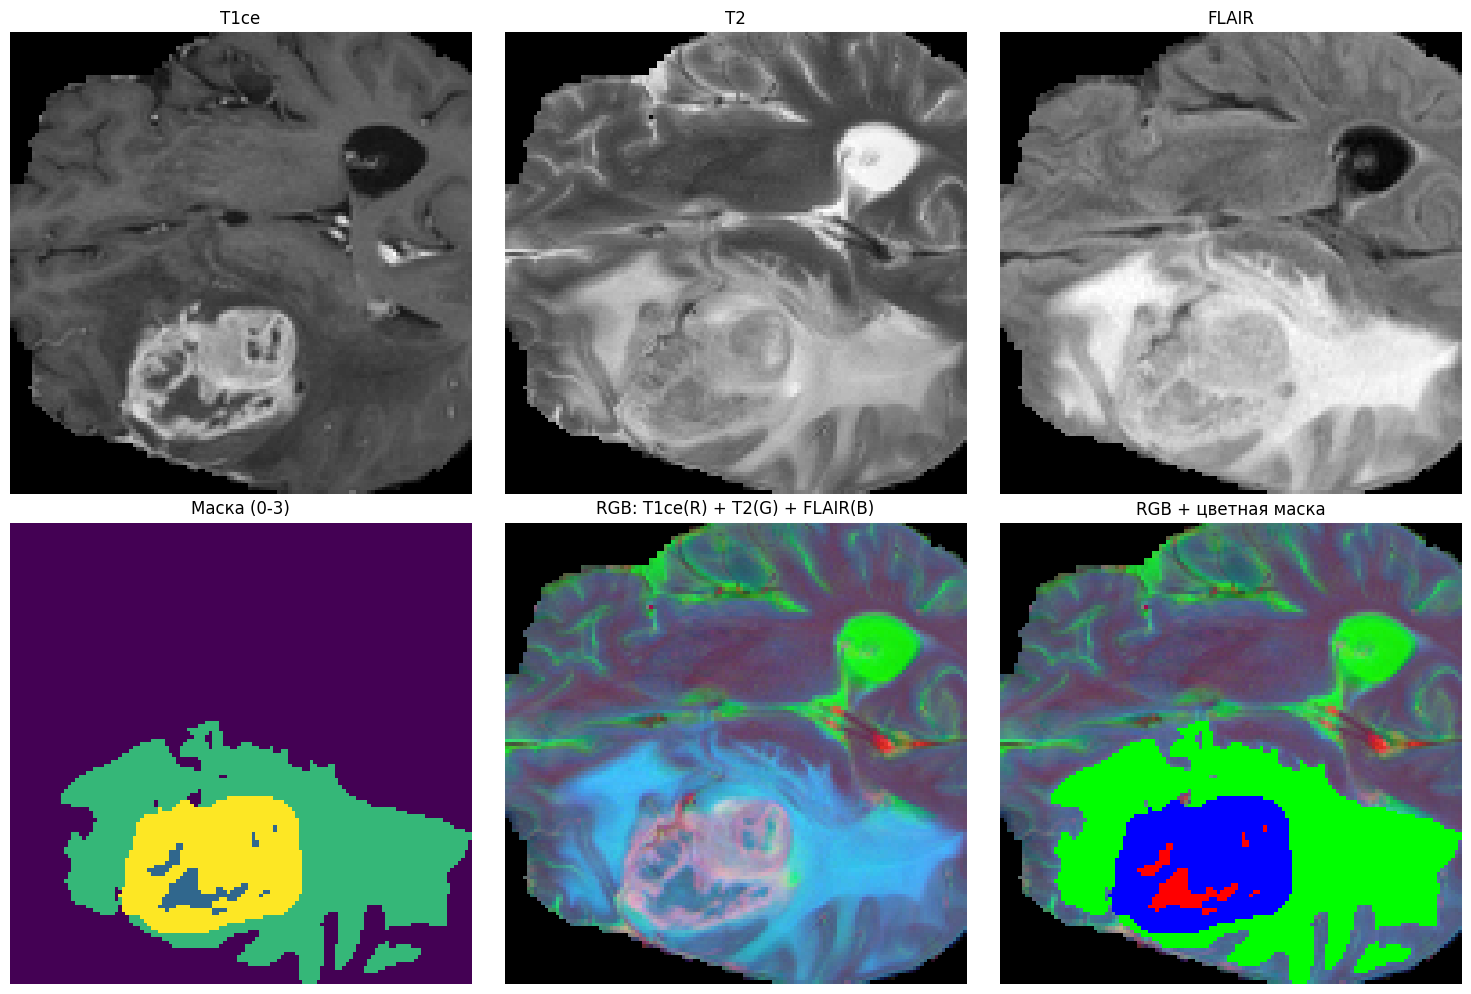

In [17]:
val_gen = patient_generator(
    patients_dir='/mnt/e/BRaTS/archive (1)/split_data/val/MRIs/',
    batch_size=8  # Маленький батч для проверки
)
check_generator(train_gen)

# Создание и компиляция модели

In [15]:
model = UNet2D(input_size=(128, 128, 3), num_classes=4)

LR = 0.0001
optimizer = Adam(learning_rate=LR)

metrics = ['categorical_accuracy', dice_score_for_loss, dice_score_wt_hard, dice_score_tc_hard, dice_score_et_hard, mean_brats_dice_hard]
t_loss = combined_loss

model.compile(optimizer=optimizer, loss=t_loss, metrics=metrics)

model.summary()

I0000 00:00:1779133456.901444    3813 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,760,196 (29.60 MB)

 Trainable params: 7,760,196 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

# Настройка коллбэков и обучение

In [16]:
os.makedirs('/mnt/e/BRaTS/archive (1)/saved_models', exist_ok=True)

In [16]:
train_gen = patient_generator(
    patients_dir='/mnt/e/BRaTS/archive (1)/Processed_Data/train/MRIs/',
    batch_size=32, 
    shuffle=True
)

val_gen = patient_generator(
    patients_dir='/mnt/e/BRaTS/archive (1)/Processed_Data/val/MRIs/',
    batch_size=32,
    shuffle=False  
)

train_patients_dir = '/mnt/e/BRaTS/archive (1)/Processed_Data/train/MRIs/'
train_patient_files = [f for f in os.listdir(train_patients_dir) 
                      if f.startswith('BraTS2021_') and f.endswith('.npy')]
num_train_patients = len(train_patient_files)
slices_per_patient = 128  # каждый пациент имеет 128 срезов
total_train_slices = num_train_patients * slices_per_patient

# Аналогично для валидации
val_patients_dir = '/mnt/e/BRaTS/archive (1)/Processed_Data/val/MRIs/'
val_patient_files = [f for f in os.listdir(val_patients_dir) 
                    if f.startswith('BraTS2021_') and f.endswith('.npy')]
num_val_patients = len(val_patient_files)
total_val_slices = num_val_patients * slices_per_patient

print(f"Обучающие данные: {num_train_patients} пациентов, {total_train_slices} срезов")
print(f"Валидационные данные: {num_val_patients} пациентов, {total_val_slices} срезов")

batch_size = 32
steps_per_epoch = total_train_slices // batch_size
validation_steps = total_val_slices // batch_size

print(f"\nBatch size: {batch_size}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

Обучающие данные: 1000 пациентов, 128000 срезов
Валидационные данные: 125 пациентов, 16000 срезов

Batch size: 32
Steps per epoch: 4000
Validation steps: 500


In [17]:
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=20, 
    validation_data=val_gen,
    validation_steps=validation_steps,
    verbose=1
)

KeyboardInterrupt: 

In [102]:
print("\nСохранение финальной модели...")
model.save('/mnt/e/BRaTS/archive (1)/saved_models/unet_brats_to_UPENN.h5')
print("Финальная модель сохранена!")


Сохранение финальной модели...
Финальная модель сохранена!


In [15]:
def load_trained_model(model_path, custom_objects=None):
    """
    Загружает обученную модель с кастомными функциями
    """
    if custom_objects is None:
        custom_objects = {
            'dice_coefficient': dice_coefficient,
            'dice_score_for_loss': dice_score_for_loss,
            'combined_loss': combined_loss,
            'dice_score_wt_hard': dice_score_wt_hard,
            'dice_score_tc_hard': dice_score_tc_hard,
            'dice_score_et_hard': dice_score_et_hard,
            'mean_brats_dice_hard': mean_brats_dice_hard
        }
    
    print(f"Загружаю модель из {model_path}")
    model = load_model(model_path, custom_objects=custom_objects)
    print("Модель успешно загружена!")
    return model

In [104]:
model = load_trained_model('/mnt/e/BRaTS/archive (1)/saved_models/unet_brats_final_combined.h5')
LR = 0.0001
optimizer = Adam(learning_rate=LR)

metrics = ['categorical_accuracy', dice_score_for_loss, dice_score_wt_hard, dice_score_tc_hard, dice_score_et_hard, mean_brats_dice_hard]
t_loss = combined_loss
model.compile(optimizer=optimizer, loss=t_loss, metrics=metrics)

Загружаю модель из /mnt/e/BRaTS/archive (1)/saved_models/unet_brats_final_combined.h5


Модель успешно загружена!


In [82]:
history_continued = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=2, 
    validation_data=val_gen,
    validation_steps=validation_steps,
    verbose=1
)

Epoch 1/2
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1514s 370ms/step - categorical_accuracy: 0.9848 - dice_score_et_hard: 0.7045 - dice_score_for_loss: 0.7242 - dice_score_tc_hard: 0.7664 - dice_score_wt_hard: 0.8533 - loss: 0.1708 - mean_brats_dice_hard: 0.7747 - val_categorical_accuracy: 0.9874 - val_dice_score_et_hard: 0.7633 - val_dice_score_for_loss: 0.4881 - val_dice_score_tc_hard: 0.7628 - val_dice_score_wt_hard: 0.7839 - val_loss: 0.2816 - val_mean_brats_dice_hard: 0.7700
Epoch 2/2
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1468s 367ms/step - categorical_accuracy: 0.9867 - dice_score_et_hard: 0.7456 - dice_score_for_loss: 0.7574 - dice_score_tc_hard: 0.8061 - dice_score_wt_hard: 0.8708 - loss: 0.1497 - mean_brats_dice_hard: 0.8075 - val_categorical_accuracy: 0.9883 - val_dice_score_et_hard: 0.7795 - val_dice_score_for_loss: 0.5024 - val_dice_score_tc_hard: 0.7927 - val_dice_score_wt_hard: 0.7703 - val_loss: 0.2800 - val_mean_brats_dice_hard: 0.7808


In [112]:
history_continued_2 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=20, 
    validation_data=val_gen,
    validation_steps=validation_steps,
    verbose=1
)

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1508s 369ms/step - categorical_accuracy: 0.9878 - dice_score_et_hard: 0.7728 - dice_score_for_loss: 0.7813 - dice_score_tc_hard: 0.8296 - dice_score_wt_hard: 0.8772 - loss: 0.1353 - mean_brats_dice_hard: 0.8265 - val_categorical_accuracy: 0.9851 - val_dice_score_et_hard: 0.6395 - val_dice_score_for_loss: 0.4822 - val_dice_score_tc_hard: 0.6593 - val_dice_score_wt_hard: 0.6639 - val_loss: 0.2882 - val_mean_brats_dice_hard: 0.6542
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1473s 368ms/step - categorical_accuracy: 0.9886 - dice_score_et_hard: 0.7865 - dice_score_for_loss: 0.8029 - dice_score_tc_hard: 0.8434 - dice_score_wt_hard: 0.8896 - loss: 0.1225 - mean_brats_dice_hard: 0.8398 - val_categorical_accuracy: 0.9891 - val_dice_score_et_hard: 0.7598 - val_dice_score_for_loss: 0.5205 - val_dice_score_tc_hard: 0.7760 - val_dice_score_wt_hard: 0.7737 - val_loss: 0.2628 - val_mean_brats_dice_hard: 0.7698
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1441s 36


KeyboardInterrupt: <exception str() failed>



# Визуализация результатов обучения

Для 14 эпох

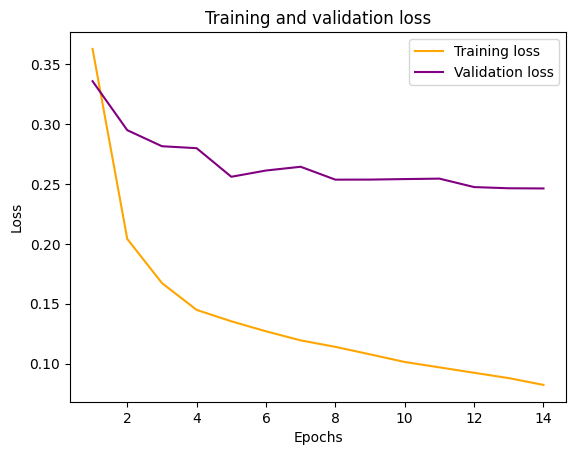

In [107]:
loss = history.history['loss'] + history_continued.history['loss'] + history_continued_2.history['loss']
val_loss = history.history['val_loss']  + history_continued.history['val_loss'] + history_continued_2.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, color='orange', label='Training loss')
plt.plot(epochs, val_loss, color='purple', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

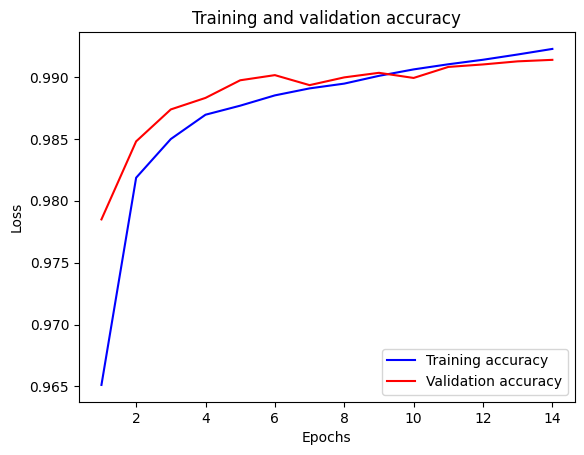

In [108]:
acc = history.history['categorical_accuracy']  + history_continued.history['categorical_accuracy'] + history_continued_2.history['categorical_accuracy']

val_acc = history.history['val_categorical_accuracy']  + history_continued.history['val_categorical_accuracy'] + history_continued_2.history['val_categorical_accuracy']

epochs = range(1, len(loss) + 1)
plt.plot(epochs, acc, color='blue', label='Training accuracy')
plt.plot(epochs, val_acc, color='red' , label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

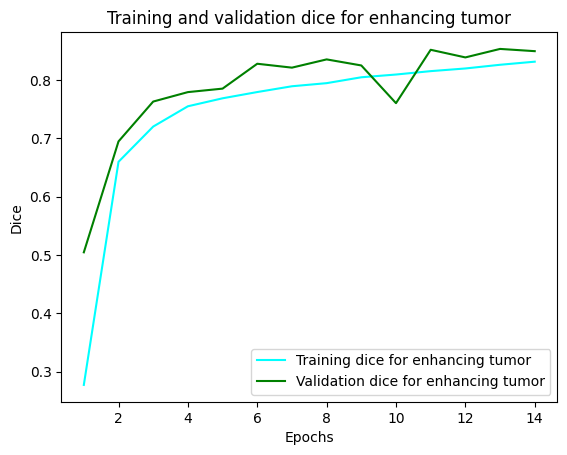

In [109]:
dice_et = history.history['dice_score_et_hard'] + history_continued.history['dice_score_et_hard'] + history_continued_2.history['dice_score_et_hard']
val_dice_et = history.history['val_dice_score_et_hard'] + history_continued.history['val_dice_score_et_hard'] + history_continued_2.history['val_dice_score_et_hard']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, dice_et, color='cyan', label='Training dice for enhancing tumor')
plt.plot(epochs, val_dice_et, color='green', label='Validation dice for enhancing tumor')
plt.title('Training and validation dice for enhancing tumor')
plt.xlabel('Epochs')
plt.ylabel('Dice')
plt.legend()
plt.show()

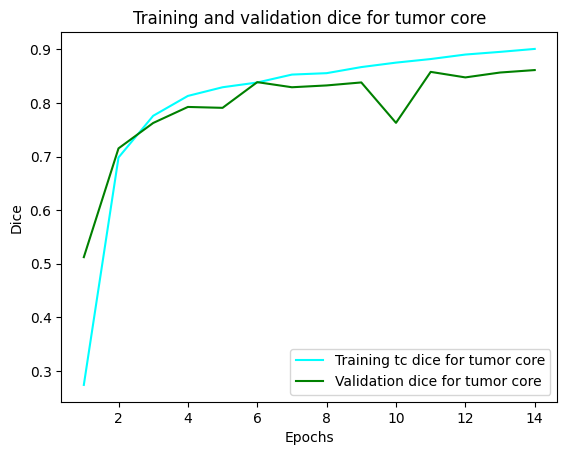

In [110]:
dice_tc = history.history['dice_score_tc_hard'] + history_continued.history['dice_score_tc_hard'] + history_continued_2.history['dice_score_tc_hard']
val_dice_tc = history.history['val_dice_score_tc_hard'] + history_continued.history['val_dice_score_tc_hard'] + history_continued_2.history['val_dice_score_tc_hard']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, dice_tc, color='cyan', label='Training tc dice for tumor core')
plt.plot(epochs, val_dice_tc, color='green', label='Validation dice for tumor core')
plt.title('Training and validation dice for tumor core')
plt.xlabel('Epochs')
plt.ylabel('Dice')
plt.legend()
plt.show()

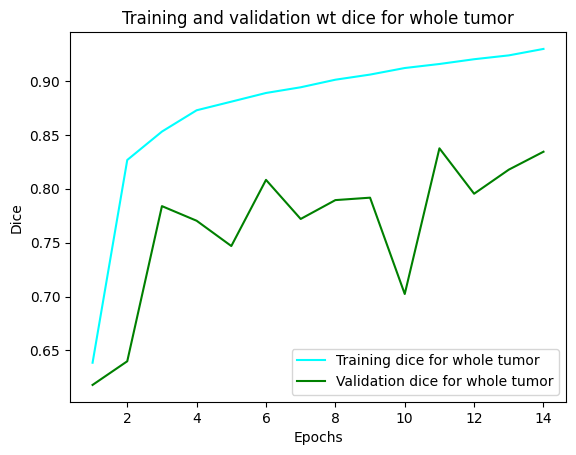

In [111]:
dice_wt = history.history['dice_score_wt_hard'] + history_continued.history['dice_score_wt_hard'] + history_continued_2.history['dice_score_wt_hard']
val_dice_wt = history.history['val_dice_score_wt_hard']  + history_continued.history['val_dice_score_wt_hard'] + history_continued_2.history['val_dice_score_wt_hard']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, dice_wt, color='cyan', label='Training dice for whole tumor')
plt.plot(epochs, val_dice_wt, color='green', label='Validation dice for whole tumor')
plt.title('Training and validation wt dice for whole tumor')
plt.xlabel('Epochs')
plt.ylabel('Dice')
plt.legend()
plt.show()

# Тестирование и визуализация предсказаний

In [16]:
def evaluate_model(model):
    test_dir = '/mnt/e/BRaTS/archive (1)/split_data/test/'
    
    test_gen = patient_generator(
        patients_dir=test_dir + 'MRIs/',
        batch_size=32,
        shuffle=False
    )
    
    # Подсчет количества тестовых срезов
    test_patient_files = [f for f in os.listdir(test_dir + 'MRIs/') 
                         if f.startswith('MRI_') and f.endswith('.npy')]
    total_test_slices = len(test_patient_files) * 128
    test_steps = total_test_slices // 32
    
    print(f"Оценка на тестовых данных: {len(test_patient_files)} пациентов")
    
    results = model.evaluate(test_gen, steps=test_steps, verbose=1)
    
    # Вывод результатов
    metrics_names = ['loss', 'categorical_accuracy', 'dice_score_for_loss', 
                     'dice_score_wt_hard', 'dice_score_tc_hard', 'dice_score_et_hard']
    
    print("\nРезультаты оценки:")
    for name, value in zip(metrics_names, results):
        print(f"{name}: {value:.4f}")
    
    return results

In [17]:
def visualize_random_mri_with_masks(model):
    test_dir = '/mnt/e/BRaTS/archive (1)/split_data/test/'
    
    mri_files = [f for f in os.listdir(test_dir + 'MRIs/') 
                if f.startswith('MRI_') and f.endswith('.npy')]
    
    if not mri_files:
        print("Нет тестовых данных!")
        return
    
    random_file = random.choice(mri_files)
    patient_id = random_file[4:-4]
    
    mri_data = np.load(test_dir + 'MRIs/' + random_file)  # (128, 128, 128, 3)
    true_mask = np.load(test_dir + 'masks/' + f'mask_{patient_id}.npy')  # (128, 128, 128, 4)
    
    slice_indices = random.sample(range(mri_data.shape[2]), 3)
    slice_indices.sort()
    
    predictions = []
    for slice_idx in slice_indices:
        slice_mri = mri_data[:, :, slice_idx, :]
        pred = model.predict(np.expand_dims(slice_mri, 0), verbose=0)[0]
        predictions.append(pred)
    
    fig, axes = plt.subplots(3, 6, figsize=(18, 9))
    
    for i, (slice_idx, pred) in enumerate(zip(slice_indices, predictions)):
        axes[i, 0].imshow(mri_data[:, :, slice_idx, 0], cmap='gray')
        axes[i, 0].set_title(f'Slice {slice_idx}: T1ce')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mri_data[:, :, slice_idx, 1], cmap='gray')
        axes[i, 1].set_title('T2')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(mri_data[:, :, slice_idx, 2], cmap='gray')
        axes[i, 2].set_title('FLAIR')
        axes[i, 2].axis('off')
        
        rgb_mri = np.stack([
            mri_data[:, :, slice_idx, 0],  # T1ce -> Red
            mri_data[:, :, slice_idx, 1],  # T2 -> Green
            mri_data[:, :, slice_idx, 2]   # FLAIR -> Blue
        ], axis=-1)
        
        for ch in range(3):
            channel = rgb_mri[:, :, ch]
            rgb_mri[:, :, ch] = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
        
        axes[i, 3].imshow(rgb_mri)
        axes[i, 3].set_title('RGB Combined')
        axes[i, 3].axis('off')
        
        true_mask_slice = true_mask[:, :, slice_idx, :]
        true_mask_classes = np.argmax(true_mask_slice, axis=-1)
        axes[i, 4].imshow(true_mask_classes, vmin=0, vmax=3)
        axes[i, 4].set_title('True Mask')
        axes[i, 4].axis('off')
        
        pred_classes = np.argmax(pred, axis=-1)
        axes[i, 5].imshow(pred_classes, vmin=0, vmax=3)
        axes[i, 5].set_title('Predicted Mask')
        axes[i, 5].axis('off')
    
    plt.suptitle(f'Patient: {patient_id} - MRI and Mask Visualization', fontsize=16)
    plt.tight_layout()
    plt.show()

In [86]:
test_results = evaluate_model(model)

Оценка на тестовых данных: 126 пациентов
504/504 ━━━━━━━━━━━━━━━━━━━━ 170s 338ms/step - categorical_accuracy: 0.9791 - dice_score_et_hard: 0.7535 - dice_score_for_loss: 0.4532 - dice_score_tc_hard: 0.7382 - dice_score_wt_hard: 0.7053 - loss: 0.3466 - mean_brats_dice_hard: 0.7323

Результаты оценки:
loss: 0.3060
categorical_accuracy: 0.9849
dice_score_for_loss: 0.4845
dice_score_wt_hard: 0.7311
dice_score_tc_hard: 0.7946
dice_score_et_hard: 0.7943


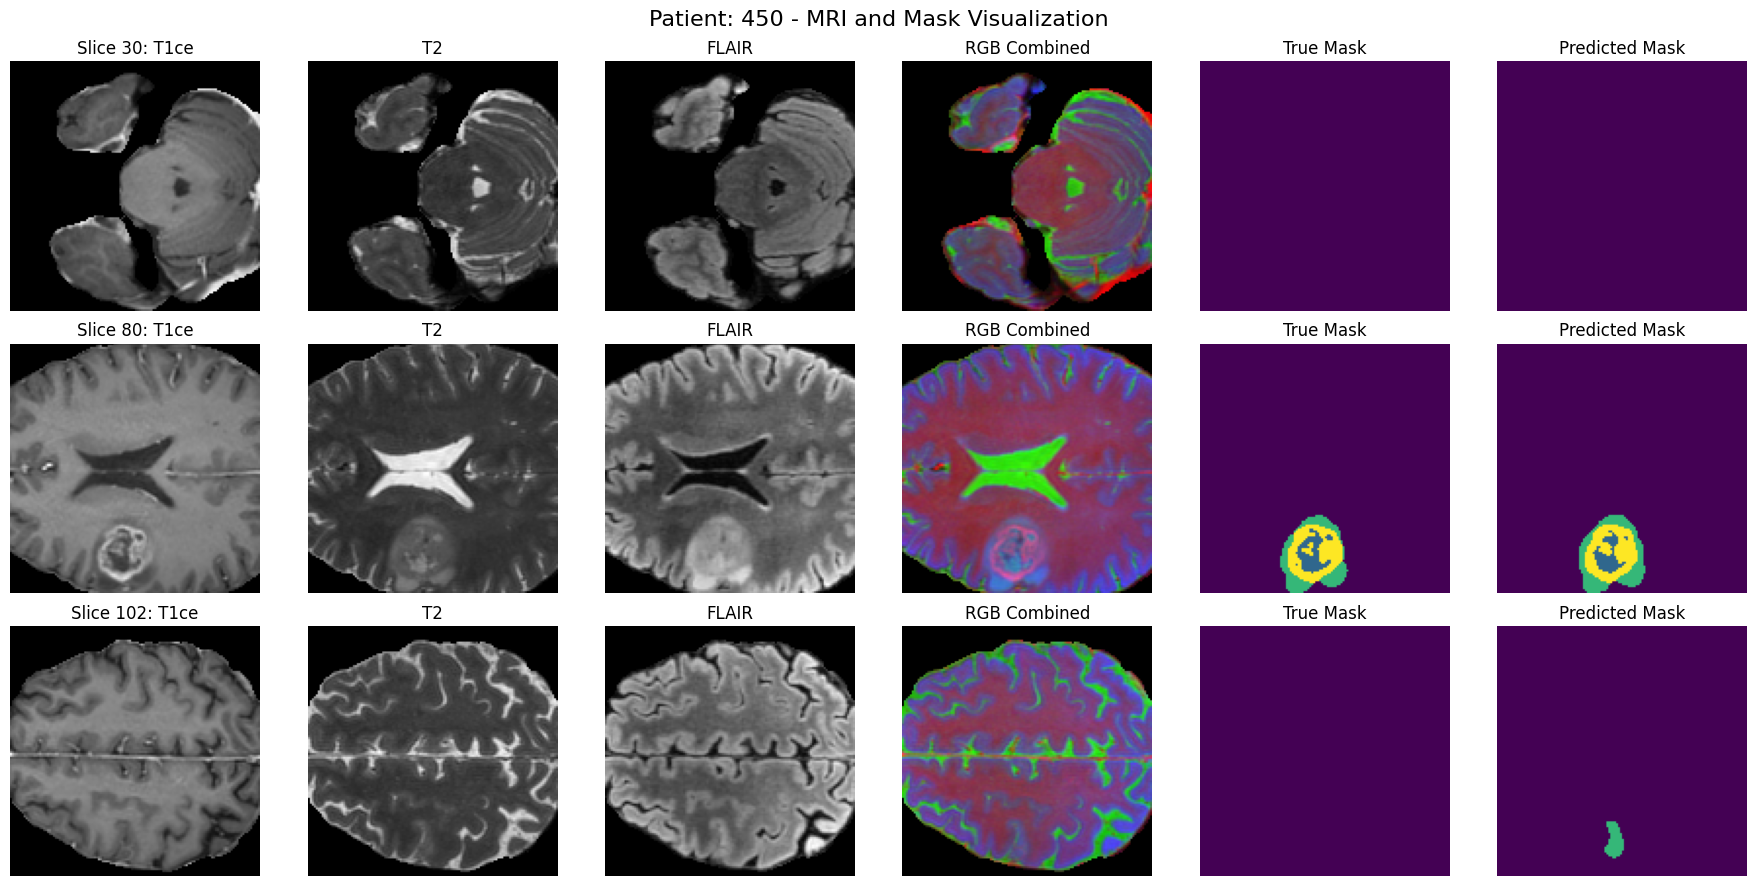

In [91]:
visualize_random_mri_with_masks(model)

После еще 10 эпох

In [95]:
test_results = evaluate_model(model)

Оценка на тестовых данных: 126 пациентов
504/504 ━━━━━━━━━━━━━━━━━━━━ 172s 341ms/step - categorical_accuracy: 0.9853 - dice_score_et_hard: 0.7840 - dice_score_for_loss: 0.5156 - dice_score_tc_hard: 0.7974 - dice_score_wt_hard: 0.7983 - loss: 0.2775 - mean_brats_dice_hard: 0.7932

Результаты оценки:
loss: 0.2555
categorical_accuracy: 0.9895
dice_score_for_loss: 0.5375
dice_score_wt_hard: 0.8278
dice_score_tc_hard: 0.8492
dice_score_et_hard: 0.8373


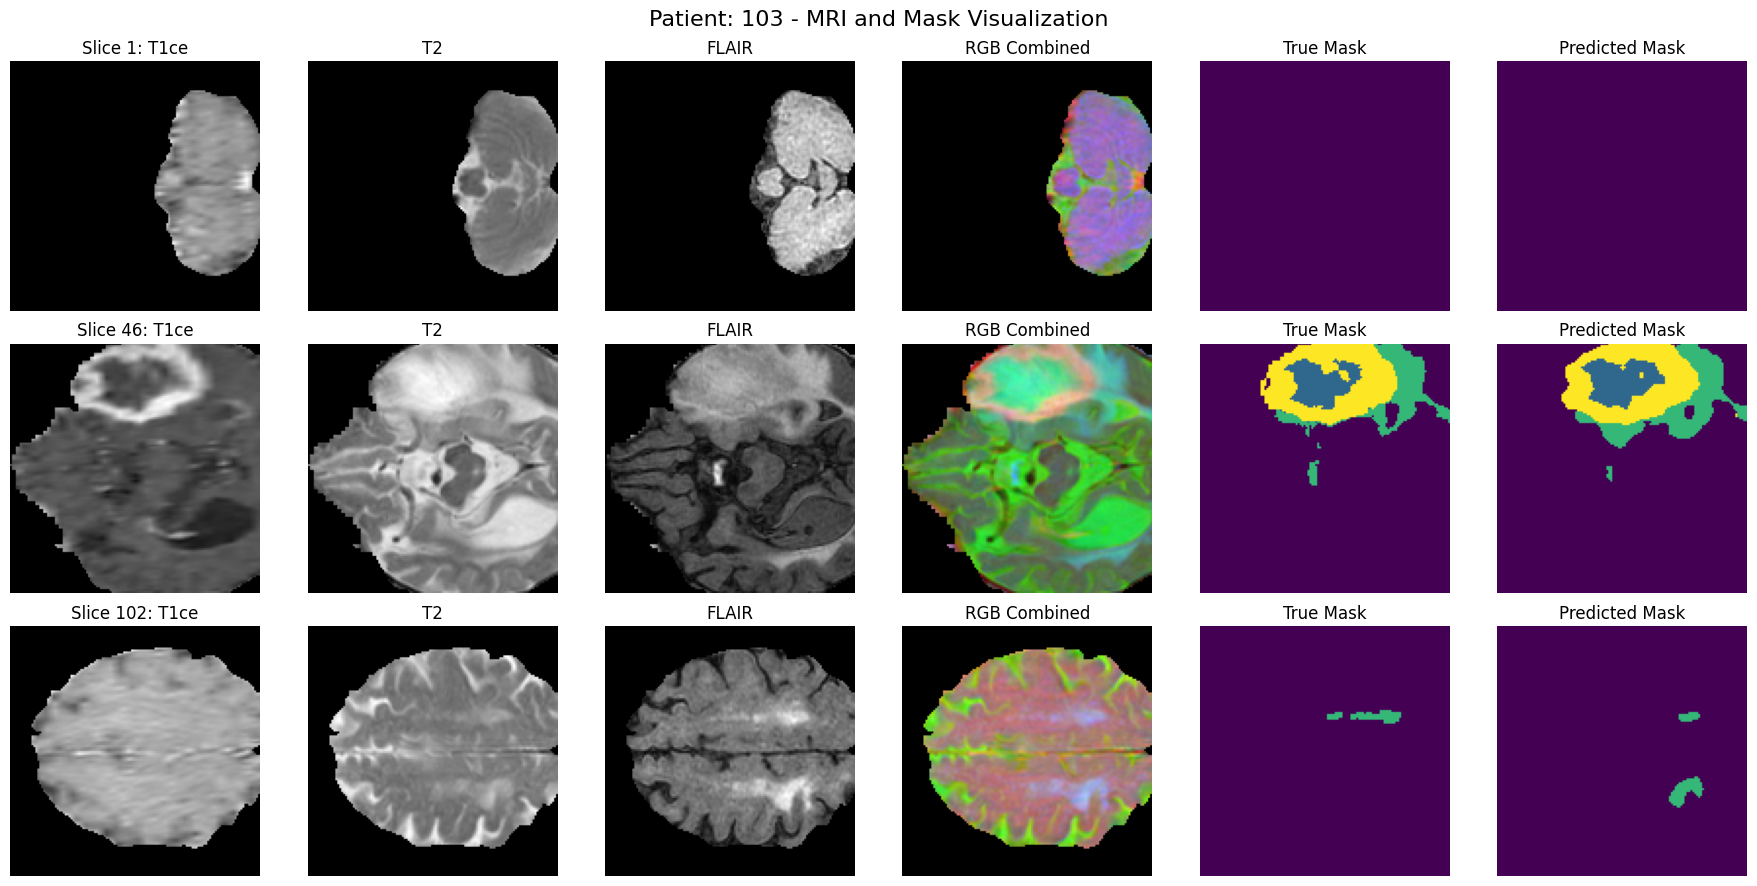

In [101]:
visualize_random_mri_with_masks(model)

# Тестирование модели на UPENN-GBM

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os
import nibabel as nib
import random
import glob
from tensorflow.keras.utils import to_categorical

def load_and_preprocess_patient(mri_path, mask_path):
    mri_3d = np.load(mri_path) 
    mask_3d = np.load(mask_path)  # (128, 128, 128, 4)
    
    return mri_3d, mask_3d

def predict_and_reconstruct(model, mri_3d, batch_size=32):
    num_slices = mri_3d.shape[2]
    predictions = np.zeros((128, 128, num_slices, 4))
    
    for i in range(0, num_slices, batch_size):
        batch_end = min(i + batch_size, num_slices)
        batch_slices = mri_3d[:, :, i:batch_end, :]
        
        batch_for_pred = np.transpose(batch_slices, (2, 0, 1, 3))
        
        batch_pred = model.predict(batch_for_pred, verbose=0)
        
        predictions[:, :, i:batch_end, :] = np.transpose(batch_pred, (1, 2, 0, 3))
    
    return predictions

def reconstruct_to_original_size(predictions_128, original_shape=(240, 240, 155)):
    full_pred = np.zeros((*original_shape, predictions_128.shape[-1]))
    
    full_pred[56:184, 56:184, 13:141, :] = predictions_128
    
    return full_pred

def save_prediction_as_nifti(prediction_3d, original_nifti_path, output_path):
    original_nifti = nib.load(original_nifti_path)
    
    if len(prediction_3d.shape) == 4:  # one-hot
        prediction_labels = np.argmax(prediction_3d, axis=-1).astype(np.uint8)
    else:
        prediction_labels = prediction_3d.astype(np.uint8)
    
    new_nifti = nib.Nifti1Image(prediction_labels, original_nifti.affine, original_nifti.header)
    
    nib.save(new_nifti, output_path)
    print(f"Сохранено: {output_path}")

def evaluate_on_new_dataset(model, test_dir, output_dir):
    predictions_dir = os.path.join(output_dir, 'predictions')
    os.makedirs(predictions_dir, exist_ok=True)
    
    mri_files = sorted(glob.glob(os.path.join(test_dir, 'MRIs', 'MRI_*.npy')))
    mask_files = sorted(glob.glob(os.path.join(test_dir, 'masks', 'mask_*.npy')))
    
    print(f"Найдено пациентов: {len(mri_files)}")
    
    all_metrics = {
        'wt_dice': [],
        'tc_dice': [],
        'et_dice': [],
        'mean_dice': [],
        'dice_per_class': {0: [], 1: [], 2: [], 3: []}
    }
    
    for idx, (mri_path, mask_path) in enumerate(zip(mri_files, mask_files)):
        print(f"\nОбработка пациента {idx + 1}/{len(mri_files)}")
        
        mri_3d, mask_3d = load_and_preprocess_patient(mri_path, mask_path)
        
        predictions_3d = predict_and_reconstruct(model, mri_3d)
        
        predictions_full = reconstruct_to_original_size(predictions_3d)
        mask_full = reconstruct_to_original_size(mask_3d)
        
        pred_labels = np.argmax(predictions_full, axis=-1).astype(np.uint8)
        
        patient_num = mri_path.split('MRI_')[-1].replace('.npy', '')
        
        original_base = r'/mnt/e/PKG - UPENN-GBM-NIfTI/splitted_dataset/test'
        original_t1ce = glob.glob(os.path.join(original_base, '*', f'*{patient_num}*.nii.gz'))
        
        if original_t1ce:
            original_nifti_path = original_t1ce[0]
        else:
            # Если не нашли, используем любой файл из тестовой папки
            original_nifti_path = glob.glob(os.path.join(original_base, '*', '*.nii.gz'))[0]
            print(f"  Внимание: не найден оригинальный файл для пациента {patient_num}, использую другой")
        
        output_filename = f'prediction_{patient_num}.nii.gz'
        output_path = os.path.join(predictions_dir, output_filename)
        save_prediction_as_nifti(pred_labels, original_nifti_path, output_path)
        
        metrics = calculate_metrics(mask_full, predictions_full)
        
        for key in all_metrics.keys():
            if key != 'dice_per_class':
                all_metrics[key].append(metrics[key])
        
        for class_idx in range(4):
            all_metrics['dice_per_class'][class_idx].append(metrics['dice_per_class'][class_idx])
        
        print(f"  WT Dice: {metrics['wt_dice']:.4f}, TC Dice: {metrics['tc_dice']:.4f}, ET Dice: {metrics['et_dice']:.4f}")
    
    print("\n" + "="*50)
    print("СРЕДНИЕ МЕТРИКИ ПО ВСЕМ ПАЦИЕНТАМ:")
    print("="*50)
    print(f"WT Dice:  {np.mean(all_metrics['wt_dice']):.4f} ± {np.std(all_metrics['wt_dice']):.4f}")
    print(f"TC Dice:  {np.mean(all_metrics['tc_dice']):.4f} ± {np.std(all_metrics['tc_dice']):.4f}")
    print(f"ET Dice:  {np.mean(all_metrics['et_dice']):.4f} ± {np.std(all_metrics['et_dice']):.4f}")
    print(f"Mean Dice: {np.mean(all_metrics['mean_dice']):.4f} ± {np.std(all_metrics['mean_dice']):.4f}")
    print("\nDice по классам:")
    for class_idx in range(4):
        print(f"  Класс {class_idx}: {np.mean(all_metrics['dice_per_class'][class_idx]):.4f} ± {np.std(all_metrics['dice_per_class'][class_idx]):.4f}")
    
    return all_metrics

def calculate_metrics(y_true, y_pred):
    y_true_labels = np.argmax(y_true, axis=-1)
    y_pred_labels = np.argmax(y_pred, axis=-1)
    
    num_classes = y_pred.shape[-1]
    y_pred_onehot = np.eye(num_classes)[y_pred_labels]
    
    dice_per_class = {}
    for c in range(num_classes):
        intersection = np.sum(y_true[..., c] * y_pred_onehot[..., c])
        total = np.sum(y_true[..., c]) + np.sum(y_pred_onehot[..., c])
        if total > 0:
            dice_per_class[c] = 2 * intersection / (total + 1e-8)
        else:
            dice_per_class[c] = 0.0
    
    y_true_wt = np.max(y_true[..., 1:], axis=-1)
    y_pred_wt = np.max(y_pred_onehot[..., 1:], axis=-1)
    
    intersection_wt = np.sum(y_true_wt * y_pred_wt)
    total_wt = np.sum(y_true_wt) + np.sum(y_pred_wt)
    wt_dice = 2 * intersection_wt / (total_wt + 1e-8) if total_wt > 0 else 0.0
    
    y_true_tc = np.maximum(y_true[..., 1], y_true[..., 3])
    y_pred_tc = np.maximum(y_pred_onehot[..., 1], y_pred_onehot[..., 3])
    
    intersection_tc = np.sum(y_true_tc * y_pred_tc)
    total_tc = np.sum(y_true_tc) + np.sum(y_pred_tc)
    tc_dice = 2 * intersection_tc / (total_tc + 1e-8) if total_tc > 0 else 0.0
    
    y_true_et = y_true[..., 3]
    y_pred_et = y_pred_onehot[..., 3]
    
    intersection_et = np.sum(y_true_et * y_pred_et)
    total_et = np.sum(y_true_et) + np.sum(y_pred_et)
    et_dice = 2 * intersection_et / (total_et + 1e-8) if total_et > 0 else 0.0
    
    return {
        'wt_dice': wt_dice,
        'tc_dice': tc_dice,
        'et_dice': et_dice,
        'mean_dice': (wt_dice + tc_dice + et_dice) / 3,
        'dice_per_class': dice_per_class
    }

def visualize_prediction_new_dataset(model, test_dir):
    mri_files = sorted(glob.glob(os.path.join(test_dir, 'MRIs', 'MRI_*.npy')))
    mask_files = sorted(glob.glob(os.path.join(test_dir, 'masks', 'mask_*.npy')))
    
    if not mri_files:
        print("Нет данных для визуализации!")
        return
    
    random_idx = random.randint(0, len(mri_files) - 1)
    mri_path = mri_files[random_idx]
    mask_path = mask_files[random_idx]
    
    patient_id = mri_path.split('MRI_')[-1].replace('.npy', '')
    print(f"Визуализация пациента: {patient_id}")
    
    mri_3d, mask_3d = load_and_preprocess_patient(mri_path, mask_path)
    
    predictions_3d = predict_and_reconstruct(model, mri_3d)
    
    slice_indices = random.sample(range(mri_3d.shape[2]), 3)
    slice_indices.sort()
    
    fig, axes = plt.subplots(3, 6, figsize=(18, 9))
    
    for i, slice_idx in enumerate(slice_indices):
        axes[i, 0].imshow(mri_3d[:, :, slice_idx, 0], cmap='gray')
        axes[i, 0].set_title(f'Slice {slice_idx}: T1ce')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mri_3d[:, :, slice_idx, 1], cmap='gray')
        axes[i, 1].set_title('T2')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(mri_3d[:, :, slice_idx, 2], cmap='gray')
        axes[i, 2].set_title('FLAIR')
        axes[i, 2].axis('off')
        
        rgb_mri = np.stack([
            mri_3d[:, :, slice_idx, 0],
            mri_3d[:, :, slice_idx, 1],
            mri_3d[:, :, slice_idx, 2]
        ], axis=-1)
        
        for ch in range(3):
            channel = rgb_mri[:, :, ch]
            if channel.max() - channel.min() > 0:
                rgb_mri[:, :, ch] = (channel - channel.min()) / (channel.max() - channel.min())
        
        axes[i, 3].imshow(rgb_mri)
        axes[i, 3].set_title('RGB Combined')
        axes[i, 3].axis('off')
        
        true_mask_classes = np.argmax(mask_3d[:, :, slice_idx, :], axis=-1)
        axes[i, 4].imshow(true_mask_classes, vmin=0, vmax=3, cmap='viridis')
        axes[i, 4].set_title('True Mask')
        axes[i, 4].axis('off')
        
        pred_classes = np.argmax(predictions_3d[:, :, slice_idx, :], axis=-1)
        axes[i, 5].imshow(pred_classes, vmin=0, vmax=3, cmap='viridis')
        axes[i, 5].set_title('Predicted Mask')
        axes[i, 5].axis('off')
    
    plt.suptitle(f'Patient: {patient_id} - UPENN-GBM Dataset', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    metrics = calculate_metrics(mask_3d, predictions_3d)
    print(f"\nМетрики для пациента {patient_id}:")
    print(f"WT Dice: {metrics['wt_dice']:.4f}")
    print(f"TC Dice: {metrics['tc_dice']:.4f}")
    print(f"ET Dice: {metrics['et_dice']:.4f}")
    print(f"Mean Dice: {metrics['mean_dice']:.4f}")

In [19]:
model = load_trained_model('/mnt/e/BRaTS/archive (1)/saved_models/unet_brats_final_combined_14_epochs.h5')

LR = 0.0001
optimizer = Adam(learning_rate=LR)
metrics = ['categorical_accuracy', dice_score_for_loss, dice_score_wt_hard, dice_score_tc_hard, dice_score_et_hard, mean_brats_dice_hard]
t_loss = combined_loss
model.compile(optimizer=optimizer, loss=t_loss, metrics=metrics)


Загружаю модель из /mnt/e/BRaTS/archive (1)/saved_models/unet_brats_final_combined_14_epochs.h5


I0000 00:00:1780239811.706762   33375 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Модель успешно загружена!


Загружаю модель из /mnt/e/BRaTS/archive (1)/saved_models/unet_brats_final_combined_14_epochs.h5


I0000 00:00:1780234776.441361     875 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Модель успешно загружена!
Найдено пациентов: 122

Обработка пациента 1/122


I0000 00:00:1780234779.781805    8891 service.cc:152] XLA service 0x7c7fc400ce50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780234779.781847    8891 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2026-05-31 16:39:40.512794: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780234781.910560    8891 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-05-31 16:39:47.124631: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng20{k2=2,k4=1,k5=0,k6=0,k7=0,k19=0} for conv %cudnn-conv-bias-activation.57 = (f32[32,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,128,128]{3,2,1,0} %bitcast.737, f32[32,3,3,3]{3,2,1,0} %bitcast.744, f32[32]{0} %bitcast.746), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$c

Сохранено: /mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test/predictions/prediction_0.nii.gz
  WT Dice: 0.9655, TC Dice: 0.9684, ET Dice: 0.9469

Обработка пациента 2/122
Сохранено: /mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test/predictions/prediction_1.nii.gz
  WT Dice: 0.8679, TC Dice: 0.9485, ET Dice: 0.9300

Обработка пациента 3/122
Сохранено: /mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test/predictions/prediction_10.nii.gz
  WT Dice: 0.9809, TC Dice: 0.9776, ET Dice: 0.9177

Обработка пациента 4/122
  Внимание: не найден оригинальный файл для пациента 100, использую другой
Сохранено: /mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test/predictions/prediction_100.nii.gz
  WT Dice: 0.9399, TC Dice: 0.9406, ET Dice: 0.9479

Обработка пациента 5/122
Сохранено: /mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test/predictions/prediction_101.nii.gz
  WT Dice: 0.9757, TC Dice: 0.9705, ET Dice: 0.9590

Обработка пациента 6/122
  Внимание: не найден оригинальный файл для пациента 102, использую другой
Сохранено: /mnt/e/PKG - UPENN-GBM-NIfTI/

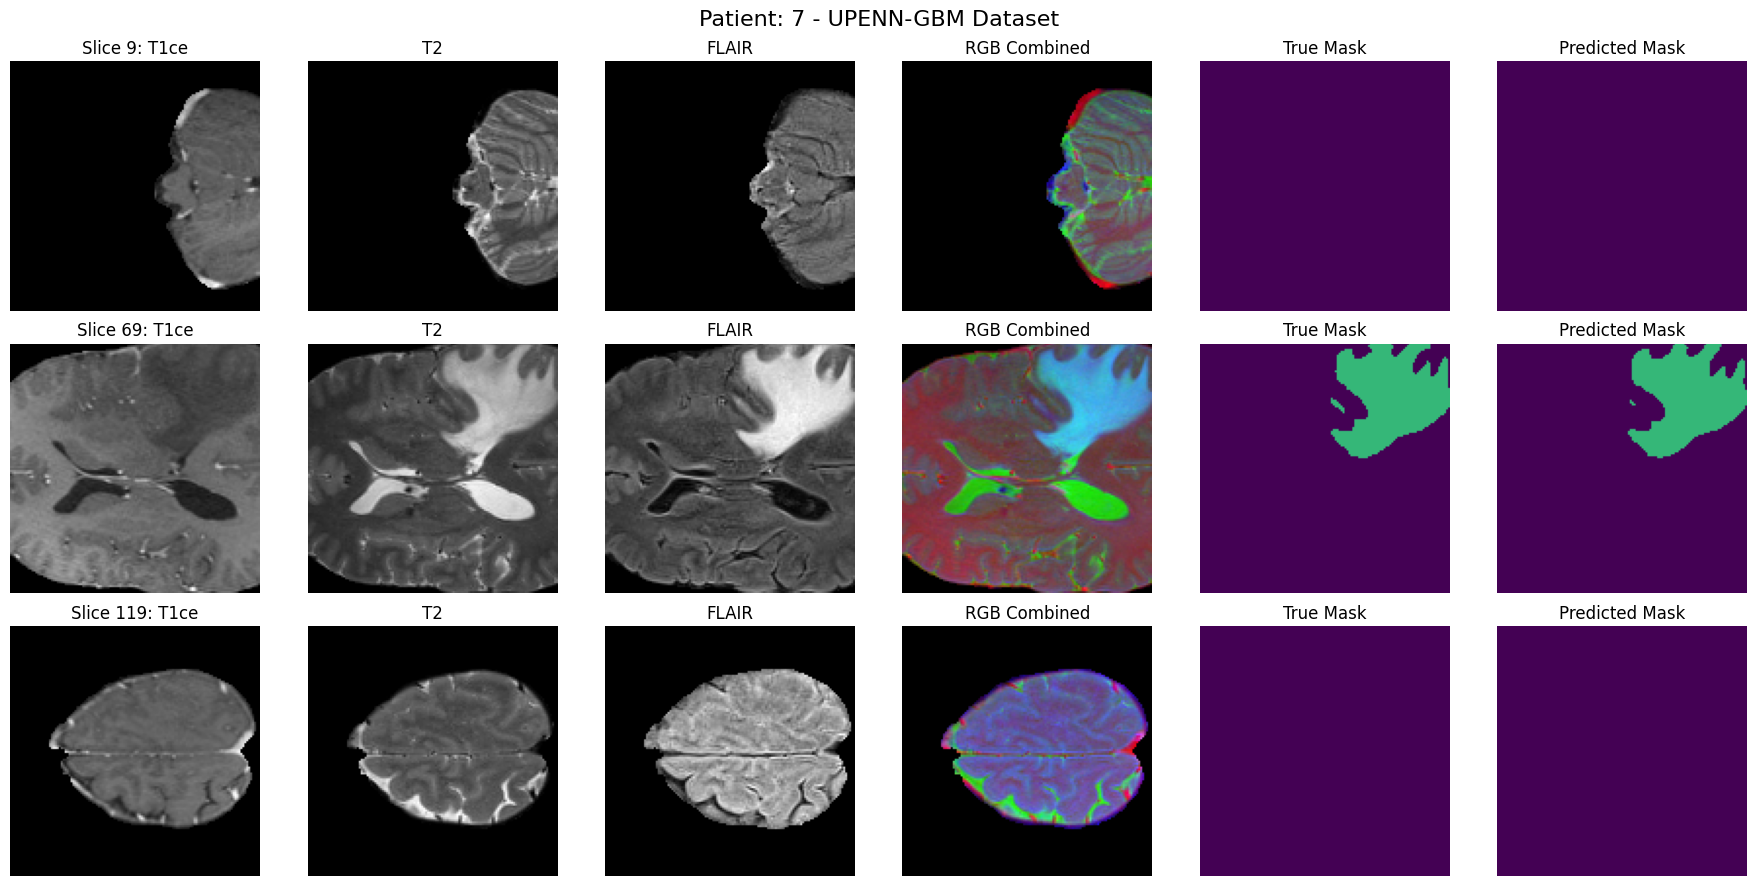


Метрики для пациента 7:
WT Dice: 0.9705
TC Dice: 0.9663
ET Dice: 0.9404
Mean Dice: 0.9590

Готово! Предсказания сохранены в: /mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test/predictions


In [20]:
test_dir = r'/mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test'
output_dir = r'/mnt/e/PKG - UPENN-GBM-NIfTI/U-Net test'

all_metrics = evaluate_on_new_dataset(model, test_dir, output_dir)

print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ ПРИМЕРА ПРЕДСКАЗАНИЯ")
print("="*60)
visualize_prediction_new_dataset(model, test_dir)

print("\nГотово! Предсказания сохранены в:", os.path.join(output_dir, 'predictions'))

Визуализация пациента: 48


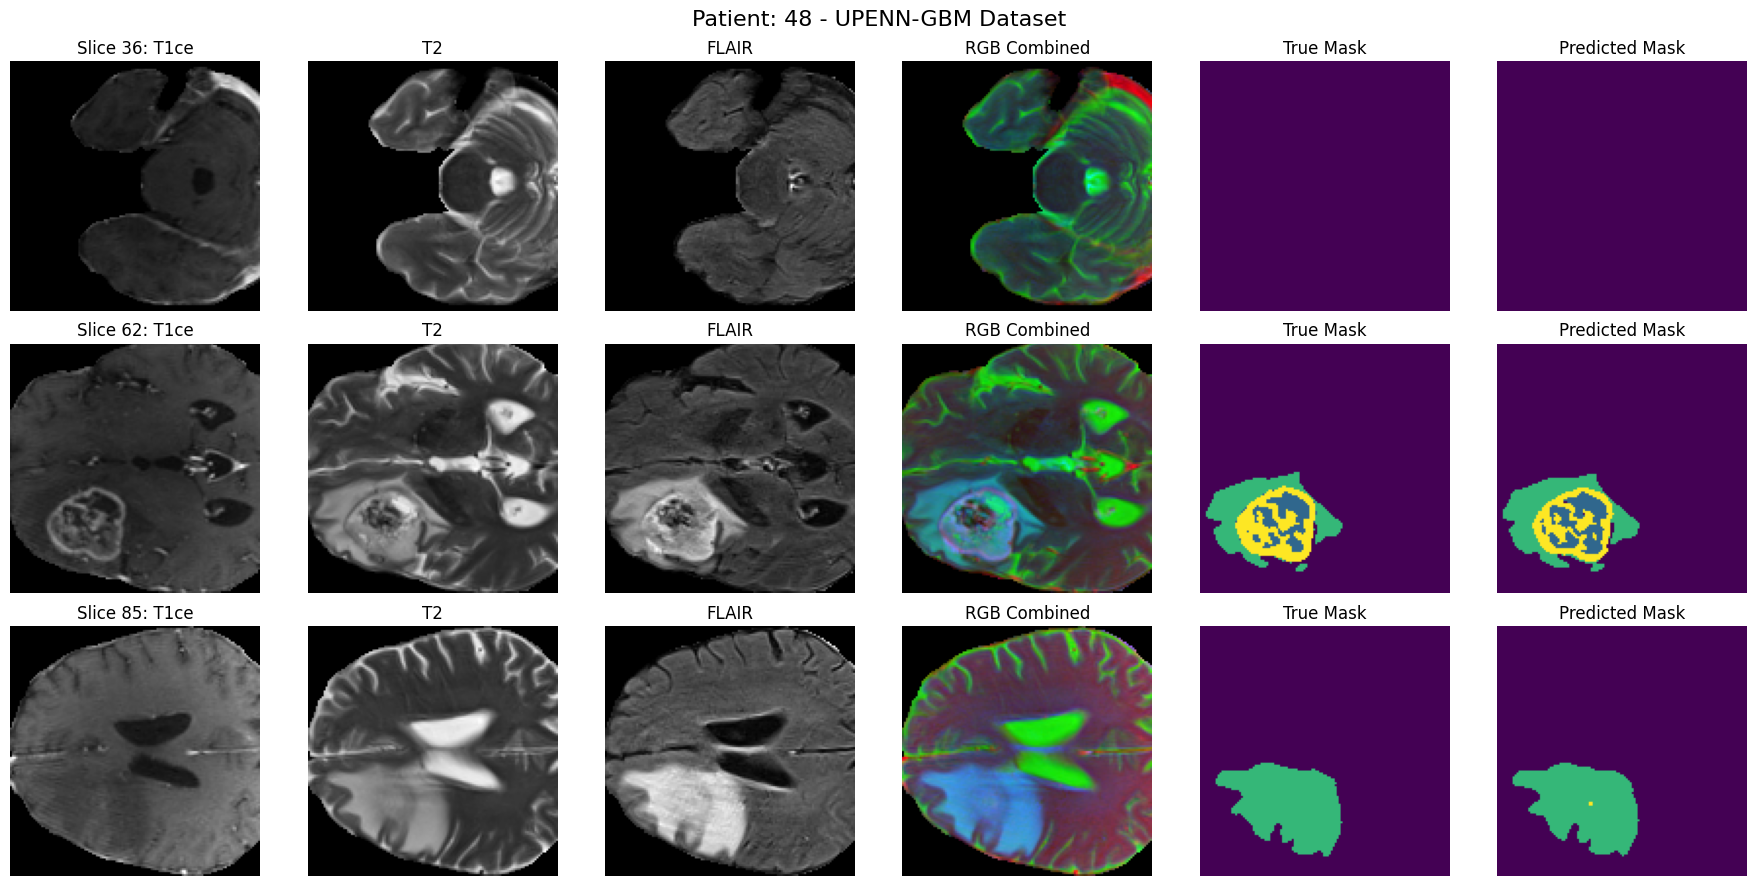


Метрики для пациента 48:
WT Dice: 0.9772
TC Dice: 0.9734
ET Dice: 0.9171
Mean Dice: 0.9559


In [24]:
visualize_prediction_new_dataset(model, test_dir)

In [20]:
print("\n" + "="*60)
print("ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ BraTS")
print("="*60)

test_dir = '/mnt/e/BRaTS/archive (1)/split_data/test/'
mri_files = sorted(glob.glob(os.path.join(test_dir, 'MRIs', 'MRI_*.npy')))
mask_files = sorted(glob.glob(os.path.join(test_dir, 'masks', 'mask_*.npy')))

print(f"Тестовых пациентов: {len(mri_files)}")

all_metrics = {
    'wt_dice': [],
    'tc_dice': [],
    'et_dice': [],
    'mean_dice': []
}

for idx, (mri_path, mask_path) in enumerate(zip(mri_files, mask_files)):
    mri_3d = np.load(mri_path)
    mask_3d = np.load(mask_path)
    
    predictions_3d = predict_and_reconstruct(model, mri_3d)
    
    metrics = calculate_metrics(mask_3d, predictions_3d)
    
    all_metrics['wt_dice'].append(metrics['wt_dice'])
    all_metrics['tc_dice'].append(metrics['tc_dice'])
    all_metrics['et_dice'].append(metrics['et_dice'])
    all_metrics['mean_dice'].append(metrics['mean_dice'])
    
    print(f"Пациент {idx+1}: WT={metrics['wt_dice']:.4f}, TC={metrics['tc_dice']:.4f}, ET={metrics['et_dice']:.4f}")

print("\n" + "="*50)
print("ИТОГОВЫЕ МЕТРИКИ:")
print("="*50)
print(f"WT Dice:  {np.mean(all_metrics['wt_dice']):.4f} ± {np.std(all_metrics['wt_dice']):.4f}")
print(f"TC Dice:  {np.mean(all_metrics['tc_dice']):.4f} ± {np.std(all_metrics['tc_dice']):.4f}")
print(f"ET Dice:  {np.mean(all_metrics['et_dice']):.4f} ± {np.std(all_metrics['et_dice']):.4f}")
print(f"Mean Dice: {np.mean(all_metrics['mean_dice']):.4f} ± {np.std(all_metrics['mean_dice']):.4f}")


ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ BraTS
Тестовых пациентов: 126


I0000 00:00:1780239822.435640   35141 service.cc:152] XLA service 0x79c864002780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780239822.435682   35141 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2026-05-31 18:03:43.377744: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780239825.220880   35141 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-05-31 18:03:48.811889: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng20{k2=2,k4=1,k5=0,k6=0,k7=0,k19=0} for conv %cudnn-conv-bias-activation.57 = (f32[32,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,128,128]{3,2,1,0} %bitcast.737, f32[32,3,3,3]{3,2,1,0} %bitcast.744, f32[32]{0} %bitcast.746), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$c

Пациент 1: WT=0.9180, TC=0.9388, ET=0.8636
Пациент 2: WT=0.9513, TC=0.9160, ET=0.8740
Пациент 3: WT=0.8445, TC=0.9598, ET=0.9338
Пациент 4: WT=0.9124, TC=0.8751, ET=0.7582
Пациент 5: WT=0.9066, TC=0.9397, ET=0.8883
Пациент 6: WT=0.7808, TC=0.8787, ET=0.8991
Пациент 7: WT=0.9251, TC=0.7124, ET=0.7327
Пациент 8: WT=0.9353, TC=0.7386, ET=0.0000
Пациент 9: WT=0.8906, TC=0.8003, ET=0.3373
Пациент 10: WT=0.8456, TC=0.6416, ET=0.5320
Пациент 11: WT=0.9147, TC=0.8286, ET=0.0015
Пациент 12: WT=0.8738, TC=0.4929, ET=0.6336
Пациент 13: WT=0.8889, TC=0.9019, ET=0.8563
Пациент 14: WT=0.8221, TC=0.1851, ET=0.3063
Пациент 15: WT=0.9239, TC=0.3924, ET=0.2207
Пациент 16: WT=0.9421, TC=0.8446, ET=0.7990
Пациент 17: WT=0.9330, TC=0.3932, ET=0.8130
Пациент 18: WT=0.9397, TC=0.9655, ET=0.9327
Пациент 19: WT=0.8373, TC=0.5140, ET=0.5372
Пациент 20: WT=0.9255, TC=0.9497, ET=0.9215
Пациент 21: WT=0.0698, TC=0.3184, ET=0.3272
Пациент 22: WT=0.8208, TC=0.8047, ET=0.8047
Пациент 23: WT=0.9471, TC=0.9563, ET=0.90